In [3]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
path = kagglehub.dataset_download("timoboz/tesla-stock-data-from-2010-to-2020")
print(path)

C:\Users\Dominik Hahn\.cache\kagglehub\datasets\timoboz\tesla-stock-data-from-2010-to-2020\versions\1


In [6]:
print(os.listdir(path))

csv_file = [file for file in os.listdir(path) if file.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))
df

['TSLA.csv']


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.000000,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.420000,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.920000,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.100000,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.000000,15.830000,16.110001,16.110001,6866900
...,...,...,...,...,...,...,...
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300


In [7]:
df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df = df.dropna()
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


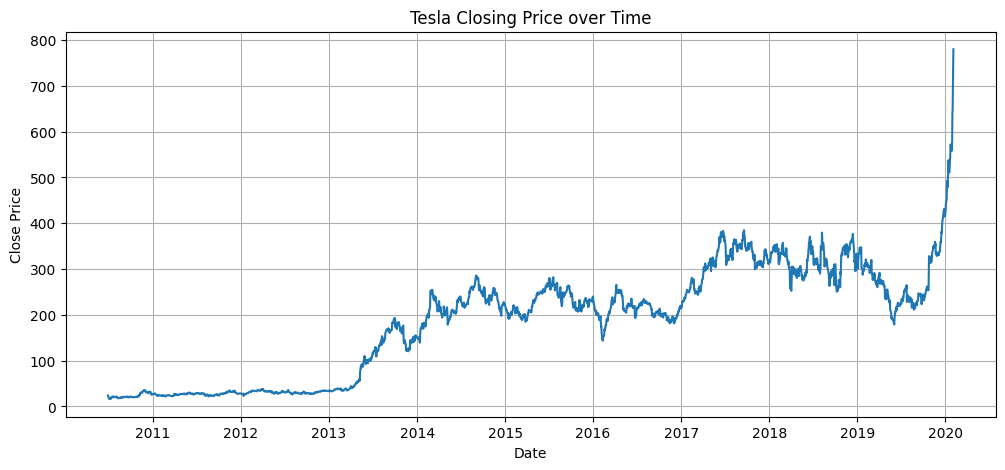

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"])
plt.title("Tesla Closing Price over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)
plt.show()

In [9]:
# Features
df["Return"] = df["Close"].pct_change()
df["MA_5"] = df["Close"].rolling(window=5).mean()
df["MA_10"] = df["Close"].rolling(window=10).mean()
df["MA_20"] = df["Close"].rolling(window=20).mean()
df["Volatility_5"] = df["Close"].rolling(window=5).std()
df["High_Low"] = df["High"] - df["Low"]
df["Open_Close"] = df["Open"] - df["Close"]

# Target
df["Target"] = df["Close"].shift(-1)
df = df.dropna()
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Return,MA_5,MA_10,MA_20,Volatility_5,High_Low,Open_Close,Target
19,2010-07-27,20.910000,21.180000,20.260000,20.549999,20.549999,619700,-0.019093,20.802,20.659,19.8715,0.418773,0.920000,0.360001,20.719999
20,2010-07-28,20.549999,20.900000,20.510000,20.719999,20.719999,467200,0.008273,20.902,20.747,19.7130,0.282614,0.390000,-0.170000,20.350000
21,2010-07-29,20.770000,20.879999,20.000000,20.350000,20.350000,616000,-0.017857,20.772,20.793,19.5390,0.364034,0.879999,0.420000,19.940001
22,2010-07-30,20.200001,20.440001,19.549999,19.940001,19.940001,426900,-0.020147,20.502,20.723,19.4380,0.383888,0.890002,0.260000,20.920000
23,2010-08-02,20.500000,20.969999,20.330000,20.920000,20.920000,718100,0.049147,20.496,20.624,19.5240,0.375273,0.639999,-0.420000,21.950001


In [12]:
features = ["Open", "High", "Low", "Close", "Volume", "Return", "MA_5", "MA_10", "MA_20", "Volatility_5", "High_Low", "Open_Close"]

X = df[features]
y = df["Target"]

In [13]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

dates_test = df["Date"].iloc[split:]

print("Training Size:", len(X_train))
print("Test Size:", len(X_test))

Training Size: 1916
Test Size: 480


In [14]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 2))

MAE: 7.69
RMSE: 12.46
R2 Score: 0.97


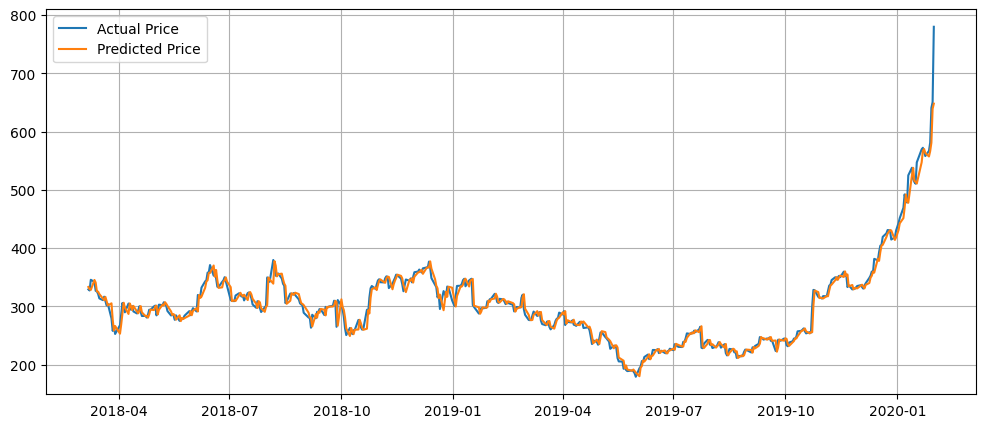

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(dates_test, y_test.values, label="Actual Price")
plt.plot(dates_test, predictions, label="Predicted Price")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
latest_data = X.iloc[[-1]]
next_prediction = model.predict(latest_data)[0]

print("Latest Date:", df["Date"].iloc[-1].date())
print("Latest close:", round(df["Close"].iloc[-1], 2))
print("Predicted next close:", round(next_prediction, 2))

Latest Date: 2020-01-31
Latest close: 650.57
Predicted next close: 648.0
